# Функции (2 занятие)

In [1]:
def foo(a, b = 42):
    return a + b

# был передан параметр по умолчанию
foo(42)

84

#### О чем надо помнить про параметры по умолчанию

Сначала должны идти обязательные параметры, и только потом необязательные (со значением по умолчанию)

In [2]:
# Вот так делать нельзя, только наоборот
def foo(a = 4, b):
    ...

SyntaxError: non-default argument follows default argument (1973019206.py, line 2)

### Первая задачка на добавление элементов в массив по умолчанию

In [3]:
def append_to_list(what, to=[]):
    to.append(what)
    return to

a = []
append_to_list(42, a)
append_to_list(43, a)

# вот такая проблемка может быть
append_to_list(42), append_to_list(42), append_to_list(42)

([42, 42, 42], [42, 42, 42], [42, 42, 42])

Разберем по порядку то, почему такая проблема возникает. Это связано в первую очередь со ссылками и то, как питон создает новые объекты

```
def append_to_list(what, to=[]):
```

Тут в параметре создается новый объект-список `to=[]` которые создается всего 1 раз на момент когда питон читает и выгружает эту функции в память. Поэтому когда мы вызовем функцию неправильно, то есть не передадим вторым параметром массив при вызове функции, то есть сделаем так:

```
append_to_list(42)
append_to_list(42)
```

то по итогу мы каждый раз будем добавлять элемент в один и тот же список `to`, который мы когда-то объявили в памяти

Еще хуже можно сделать при вызоыве функции в строку через запятую, в таком случае создается кортеж (tuple), это неизменяемый аналог обычного списка, по итогу при вызове первой функции она вернет [42], при вызове второй [42, 42], и потом так как эти фукнции возвращают не значение, а ссылку на один и тот же объект в памяти, то есть массив `to=[]`, у нас оно соберется в один двумерный массив

Аналог операции в строку выглядит вот так:

In [4]:
res1 = append_to_list(42)
res2 = append_to_list(42)
res3 = append_to_list(42)

res = [res1, res2, res3]
res

[[42, 42, 42, 42, 42, 42], [42, 42, 42, 42, 42, 42], [42, 42, 42, 42, 42, 42]]

Эта проблема может возникать со всем, что является ссылкой

### Как узанть дефолтные параметры у объекта
Дефолтные параметры объекта можно узнать следующим образом

In [6]:
append_to_list.__defaults__

([42, 42, 42, 42, 42, 42],)

Ну и как видно, тут параметр по дефолту уже не чистый массив, а загрязненный

Первый фикс данной проблемы заключается в том, что мы будем возвращать не ссылку на один и тот же массив, а будем спред оператором возвращать копию массива

In [7]:
def append_to_list(what, to=[]):
    return [*to, what]

a = []
# указатель объекта
# ids = [id(a)]

# for i in range(5):
#     a = append_to_list(42, a)
#     ids.append(id(a))

# ids
append_to_list(43)
append_to_list(43)

[43]

In [8]:
def append_to_list(what, to=[]):
    return [*to, what]

a = []
# функция id позволяет получить указатель объекта
ids = []

for i in range(5):
    a = append_to_list(42, a)
    ids.append(a)

ids
# append_to_list(43)
# append_to_list(43)


[[42], [42, 42], [42, 42, 42], [42, 42, 42, 42], [42, 42, 42, 42, 42]]

По результату видно, что получаются ращные списки, для наглядности выведем их ссылки с помощью функции `id()`

In [9]:
def append_to_list(what, to=[]):
    return [*to, what]

a = []
ids = [id(a)]
a

[]

In [10]:
for i in range(5):
    a = append_to_list(42, a)
    ids.append(id(a))

ids

[4384553280, 4390184128, 4390001408, 4390184128, 4390001408, 4390184128]

Ну и по ссылкам на объекты видно, что все списки разные

Из возможных гипотетических проблем данной реализации:
- могут совпасть адреса в памяти, если старый объект был удален сборщиком мусора, но не в данном случае так как все списки сохранены в массив ids

Но главная проблема следующая:
- В данной реализации сигнатура функции обещает добавить элемент в массив, а по факту возвращает новый список со старыми элементами и новым добавленым, а не просто добавляет в список, и это очень плохо

Поэтому можно решить задачу следующим, эталонным способом:

In [12]:
a = []
ids = [id(a)]

def append_to_list(what, to=[]):
    if to is None:
        to = []
    to.append(what)
    return to

for i in range(5):
    a = append_to_list(i, a)
    ids.append(id(a))

ids

[4390283136, 4390283136, 4390283136, 4390283136, 4390283136, 4390283136]

По айдишникам видно, что мы честно добавляем элемент в один и тот же список, потому что они одинаковые

In [13]:
a

[0, 1, 2, 3, 4]

Значения тоже все верные

Есть еще пример более запутанной реализации данной функции, который обычно не рекомендуют использовать из-за сложности чтения:

In [15]:
a = []

ids = [id(a)]

def append_to_list(what, to=None):
    # негодяй
    to = to or []

    to.append(what)

    return to

for i in range(5):
    a = append_to_list(i, a)
    ids.append(id(a))

ids

[4390274816, 4389903680, 4389903680, 4389903680, 4389903680, 4389903680]

В таком случае у нас почему-то сслыка на первый элемент отличается от всех остальных??

Это происходит из-за того, как питон сравнивает объекты%

На первой итерации to=[] пустому массиву, и в логическом сравнении пустой массив = False

То есть левая часть равна False, так как массив пустой, и возвращается новый массив, и полностью игнорирует переданный пустой массив

То есть поведение на пустой переданный массив и не переданный массив вообще в аргументы одинаковые, что как бы не правильно

Дальше мы уже передаем массив с 1 элементом и проверка to возращает его, а это массив с другим адресом

In [16]:
a = []

ids = [id(a)]

def append_to_list(what, to=None):
    to = [] if to is None else to

    to.append(what)
    return to

for i in range(5):
    a = append_to_list(i, a)
    ids.append(id(a))

ids

[4390247488, 4390247488, 4390247488, 4390247488, 4390247488, 4390247488]

## Идеалогия питона

In [17]:
# основный идеи питона
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


## Лямбда функция (анонимные функции)

В питоне по идеалогии сами разработчики рекомендуется не использовать лямбда функции

Разработчики специально в объявление анонимной функции добавили слово лямбда, чтобы отбить желание ее использовать, в других языках анонимнве функции например по другому выглядят

In [20]:
mult_l = lambda a, b: a + b

Под капотом лямбда функция это такая же фукнция как и через `def` объявленная через объект `PyFunctionObject`, за исключением того, что в поле `__name__` будет написано слово `lambda`

Лямбда функция может принимат любое кол-во параметров, но выполнит всего одно выражение, сколь угодно длинное

#### в питоне знак = (присвоить) находится на самом верхнем уровне операций

Также = - это инструкция, как и if, for, def

А операторы - это + - * and и тд

In [33]:
foo = lambda a, b: a + b
foo(1, 2)

3

В питоне нет магии, то есть любую функцию которая используется в питоне, омжно на самом питоне написать

И лямбдами стараемся не пользоваться

## Позиционные и не позиционные аргументы в функции

`*` - одна звезда говорит питону о том, что нужно собрать все позиционные параметры в эту сторону
`**` - две звезды говорят о том, что нужно все непозиционные аргументы собрать в другую сторону

In [21]:
def foo(*a, **b):
    print(a, b)

foo(1, 2, 3, a=4, b=5, d = 6)
# (1, 2, 3) {'a': 4, 'b': 5, 'd': 6}

(1, 2, 3) {'a': 4, 'b': 5, 'd': 6}


можно через звезду разделить эти элементы, но тогда мы сможем только 1 передать, а не список

In [22]:

def foo(a, *, b = 4):
    print(a, b)

foo([1, 2, 3], b = 4)

[1, 2, 3] 4


в следуюшем примере d не выведется, потому что он является параметром по ключу, а не позиционным или непозиционным

In [23]:
def foo(*a, d, **b):
    print(a, b)

foo(1, 2, 3, d = 6, a=4, b=5)


(1, 2, 3) {'a': 4, 'b': 5}


Все возможные способы передачи параметров в современном питоне

- до / - все позиционные аргументы, без имени
- между / и * - любые аргументы
- после * - только именнованные аргументы
- **kwargs - сборка всех послеидущих именованных аргументов


In [24]:

def foo(a, b, /, c, d, *, e, f, **kwargs):
    print(a, b, c, d, e, f, kwargs)

foo([1, 2, 3], 4, 3, d = 4, e = 3, g = 4, f = 4, gg = 15, dd = 33 )

[1, 2, 3] 4 3 4 3 4 {'g': 4, 'gg': 15, 'dd': 33}


Почти никто так никогда не делает, можно сделать когда функцию плохо читать и мы хотим чтобы код выглядел как дифферинцииальные уравнения

## Напишем функцию, которая складывает все числа слева

Функция, которая как факториал работает и складывает или делает действие с масивом

`reduce` - аналог такой функции, она аккумулирует значение по операции, которую мы передали, то есть мы перемножили числа. Но в питон пока `reduce` не добавили

In [25]:
import operator

def left_fold(*values, operator):
    value = values[0]

    for i in range(1, len(values)):
        value = operator(value, values[i])
    return value

left_fold(1, 2, 3, 4, 5, operator=operator.mul)

120

### Аннотации и типизация

Аннотации - они нужны для сигнатуры функции, то есть это просто документация

In [26]:
def foo(a: int, b: int) -> int:
    """Какая то ультра крутая аннотация для функции"""
    return a + b

In [27]:
foo.__annotations__

{'a': int, 'b': int, 'return': int}

In [28]:
foo.__name__

'foo'

In [29]:
foo.__doc__

'Какая то ультра крутая аннотация для функции'

Пример плохой типизации

In [ ]:
a : str = '42'

Также питон не проверяет типы на этапе компиляции, они нужны просто для документации или в дальнейшем для передачи какому-нибудь стороннему анализатору

У аннотации есть доп инструменты

In [32]:
import typing

def foo(a: typing.Union[int, float] | typing.Literal[456]) -> int | float:
    return a

foo(43)

help(foo)

Help on function foo in module __main__:

foo(a: Union[int, float, Literal[456]]) -> int | float



В лямбда функции нельзя писать аннотации

In [34]:
foo.__annotations__ = {'a' : int, 'b' : int}
foo.__defaults__ =(10,)

foo(1)

11

# Декораторы (разбор с ютуба)

Это паттерн программирования, который позволяет добавлять функционал на другие функции или классы

Другое определение - это функция, которая в качестве параметра получает другую функцию


In [ ]:
Самый базовый метод использования декоратора - определить его перед функцией через собаку 

In [ ]:
def deco():
    pass

@deco
def my_func():
    return 124

In [ ]:
Также можно просто обернуть другую функцию в декоратор, собака - это просто синтаксический сахар для написания кода

In [ ]:
def deco():
    ...

def my_func():
    return 124

# правая часть должна вернуть функцию
my_func = deco(my_func)

Какие декораторы можно написать:
- Подсчет времени выполнения функции
- Логирование параметров функции
- Повтор функции в случае ошибки
- Ограничение на частый вызов функции

Мы импортируем не тип функции, а именно вызываемый объект, Callable, то есть тот объект который можно вызвать через скобочки

Декоратор всегда параметром принимает функцию и внутри себя реализует функцию которую должен вернуть, то есть декоратор всегда возвращает функцию

In [37]:
from typing import Callable


def deco(func: Callable):
    def wrapper():
        res = func()
        return res
    
    return wrapper


@deco
def foo():
    return 124

foo()

124

Пустой декоратор примерно так и выглядит по структуре ->

In [38]:
def empty_deco(func: Callable):
    def wrapper():
        res = func()
        return res
    
    return wrapper

#### Декоратор для подсчета времени

In [39]:
from typing import Callable
import time

def log_time(function: Callable):
    def wrapper():
        start = time.time()
        res = function()
        end = time.time()
        print(f"Время выполнения функции - {end - start}")
        return res
    return wrapper

@log_time
def sleep_foo():
    time.sleep(1)

sleep_foo()

Время выполнения функции - 1.0050392150878906


#### Пример декоратора для функции с параметром

In [40]:
from typing import Callable
import time

def param_timer_foo(func: Callable):
    # мы хотим сделать универсальный декоратор, поэтому мы указыаем все параметры через деструктуризациж, позиционные и не позиционные (с ключом то есть)
    def wrapper(*args, **kwargs):
        start = time.time()
        res = func(*args, **kwargs)
        end = time.time()
        print(f"Время выполнения функции - {end - start}")
        return res

    return wrapper

@param_timer_foo
def sleep_foo(sleep_time: int):
    time.sleep(sleep_time)
    return 123

sleep_foo(2)

# так без синтаксического сахара это выглядело бы
# test = param_timer_foo(sleep_foo)(2)

Время выполнения функции - 2.005032777786255


123

#### Пример декоратора с параметрами
Напишем декоратор для функции, который можно будет вызывать всего n-кол-во раз

Для этого мы добавляем еще один новый уровень вложенности для прокидки параметров

In [41]:
def limit_calls3(limit: int):
    def wrapper(func: Callable):
        def inner(*args, **kargs):
            nonlocal limit
            if limit == 0:
                print(f'Нельзя вызвать функцию')

                return
            start = time.time()
            res = func(*args, **kargs)
            end = time.time()
            print(f'Runnig time {end - start}')
            limit -= 1

            return res
        return inner
    return wrapper


@limit_calls3(3)
def foo1(sleep: int):
    time.sleep(sleep)

foo1(1)
foo1(1)
foo1(1)
foo1(1)

Runnig time 1.0050280094146729
Runnig time 1.0007309913635254
Runnig time 1.0011508464813232
Нельзя вызвать функцию


#### Декораторы - ошибка с док стрингами и как ее исправить

In [42]:
def limit_calls3(limit: int):
    def wrapper(func: Callable):
        def inner(*args, **kargs):
            nonlocal limit
            if limit == 0:
                print(f'Нельзя вызвать функцию')

                return
            start = time.time()
            res = func(*args, **kargs)
            end = time.time()
            print(f'Runnig time {end - start}')
            limit -= 1

            return res
        return inner
    return wrapper


@limit_calls3(3)
def foo1(sleep: int):
    """Очень важный док стринг"""
    time.sleep(sleep)

# foo1(1)
# foo1(1)
# foo1(1)
# foo1(1)

# при наведении на функцию foo1 док-стринг пропадает и также ее нет в параметре
foo1.__doc__
foo1.__name__

'inner'

Чтобы избежать этой проблемы, надо использовать встроенный декоратор

In [43]:
from functools import wraps

def limit_calls3(limit: int):
    def wrapper(func: Callable):
        # Нужно именно сразу после получения функции обернуть и указать функцию которую нужно обернуть
        @wraps(func)
        def inner(*args, **kargs):
            nonlocal limit
            if limit == 0:
                print(f'Нельзя вызвать функцию')

                return
            start = time.time()
            res = func(*args, **kargs)
            end = time.time()
            print(f'Runnig time {end - start}')
            limit -= 1

            return res
        return inner
    return wrapper

@limit_calls3(3)
def foo1(sleep: int):
    """Очень важный док стринг"""
    time.sleep(sleep)

# foo1(1)
# foo1(1)
# foo1(1)
# foo1(1)

# при наведении на функцию foo1 док-стринг пропадает и также ее нет в параметре
foo1.__doc__


'Очень важный док стринг'

In [44]:
foo1.__name__

'foo1'

#### Декоратор для ассинхронной функции

Корутины (сопрограммы) - это функции, которые умеют ставить себя на паузу, освобождая ресурсы для других задач, а затем возобновляют работу с того же места. По сути это и есть ассинхронные функции.

Корутина это конкретный объект, который возвращает эта функция

Фабрика - это паттерн проектирования, который решает проблему создания объектов без указания их конкретных классов

Весь прикол в том, что я могу создать класс, у которого будет фабричный метод, который по каким-то условиям будет возвращать другие классы, и по сути станет фабрикой

In [45]:
from typing import Coroutine
import asyncio

def deco(courutine: Coroutine | Callable): # для универсальности два типа
    async def wrapper(*args, **kargs):
        res = await courutine(*args, **kargs)
        return res
    return wrapper

@deco
async def foo3(sleep_timer: int):
    await asyncio.sleep(sleep_timer)
    return 1

await foo3(2)

1

### Замыкания

Это функция, которая помнит свое лексическое окружение и имеет доступ к переменным из внешней области видимости

In [46]:
#  функция в функции

def foo(a, b):
    def bar(c, d):
        return c + d

    return a * bar(a, b) + b


foo(1, 2)

5

Это позволяет реализовать замыкания - запомнили функцией те значения функции которые были в пространстве имен этой функции

In [47]:
def foo(a, b):
    def bar(c, d):
        return b * bar(a, b) + c

    a = 10
    return bar

adds = []

for i in range(10):
    adds.append(lambda a: a + i)

adds[9](2)

11

Все функции запомнили одну и ту же лексическую область i и теперь ссылаются на нее в памяти, то есть равны все 9

Эту пробему можно решить следующим образом - для внешней переменно i которая затемняет значение внутренней i создается свое новое лексическое окружение, происходит замыкание и она грубо говоря пересоздается внутри этого лексического окружения, за счет чего является другой i и содержит другое значение

In [48]:
adds = []

for i in range(10):
    adds.append((lambda i: (lambda a: a + i))(i))

adds[8](1)

9

Ну и можно тоже самое сделать не через анонимную функцию, а через обычную

In [49]:
def make_incrementer(i):
    return lambda a: a + i

adds = []

for i in range(10):
    adds.append(make_incrementer(i))
adds[9](1)

# то есть можно вот так улучшить функцию

10

### nonlocal and global

In [50]:
def foo(a, b):
    def bar(c):
        # из-за порядка объявления питон считает a локальной переменной и в return вызовет ошибку, так как на уровне выше ее уже не существует
        a += c

    for i in range(b):
        bar(i)

    return a

foo(0, 5)

UnboundLocalError: local variable 'a' referenced before assignment

В питоне такой код не сработает потому что a всегда меняется a внутри своей функции, а выше какой был сверху

Надо использовать nonlocal - доступ к ближайшей верхнему лексическому окружению, нде есть эта переменная

In [51]:
def foo(a, b):
    def bar(c):
        nonlocal a
        a += c

    for i in range(b):
        bar(i)

    return a

foo(0, 5)

10

Если переменной нет то вызовется ошибка

global говорит что надо пойти на верхний уровень и сразу искать где то там переменнецю a, а не по дереву вызовов

не надо пользоваться такими операторами

In [ ]:
def foo(a, b):
    def bar(c):
        global a
        a += c

    for i in range(b):
        bar(i)

    return a

foo(0, 5)

### Создание динамического атрибута у объекта функции

В питоне функции являются объектами первого порядка, как строки списки и словари, поэтому у них могут свои. личные свойства (атрибуты), которые можно прям на ходу создавать через точку

Для таких ситуация в питоне можно сделать замыкание по имени функции

In [53]:

def foo(a, b):
    def bar(c):
        bar.a += c

    bar.a = a

    for i in range(b):
        bar(i)

    # вместо а возвращает а из bar, потому что а глобальные а не поменялось
    return bar.a

foo(0, 5)

# перменную внутри функции можно прописать любую таким способом

10

Еше способ для того, чтобы получить доступ к значению из другой области видимости

Тут стоит вспомнить о том, что есть изменяемые и неизменяемые данные в питоне

1) Неизменяемые - менять после создания нельзя, при попытке изменить создается другая ячейка в памяти
- Числа (int, float, complex)
- Строки
- Кортеж (tuple) (1, 2, 3)
- Логический тип (bool)
- frozenset

2) Изменяемые - такие объекты можно спокойно редактировать
- Список (list) [1, 2, 3]
- Словари (dict) {"key" : "value"}
- Множества (set) - {1, 2, 3}
- Массив байт (bytearray)

Собственно, следующая идея заключается в том, чтобы неизменямый тип привести к изменяемому, за счет этого объект не будет пересоздаваться а мы просто получим ссылку на существующий

Можно завести список, потому что состояние списка можно менять, в отличие от числа, так тоже писать надо стараться избегать

In [54]:

def foo(a, b):
    
    a = [a] 
    print(a)

    def bar(c):
        a[0] += c

    for i in range(b):
        print(a)

        bar(i)

    return a[0]

foo(1, 5)

[1]
[1]
[1]
[2]
[4]
[7]


11

Еще пример - кликер со счетчиком

Решение через оператор nonlocal

In [55]:
def create_btn():
    clicks = 0 

    def click():
        nonlocal clicks
        clicks += 1
        print(f"Клик! Всего: {clicks}")

    return click

# надо вызывать через инстанс, потому что только так значение счетчика сохранится в памяти
btn = create_btn()
btn()
btn()


Клик! Всего: 1
Клик! Всего: 2


Решение через оборот в изменяемый тип данных

In [ ]:
def create_btn():
    clicks = 0 
    clicks = [clicks]


    def click():
        clicks[0] += 1
        print(f"Клик! Всего: {clicks}")

    return click

# надо вызывать через инстанс, потому что только так значение счетчика сохранится в памяти
btn = create_btn()
btn()
btn()


### Очень быстрое вычисление корня 

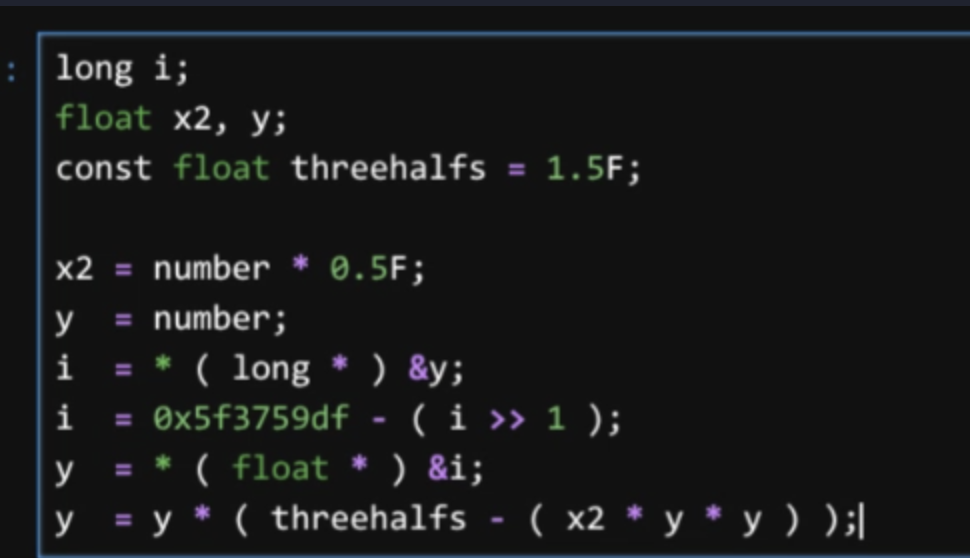

## Декораторы (с пары)

Функции - это простой объект в питоне, и с ней чисто технически можно делать тоже самое что и с числами

In [56]:
def foo(f):
    def wrapper(a, b):
        return f(2 * a, 2 * b)

    return wrapper

bar = foo(lambda a, b: a + b)
bar(1, 2)

6

Напишем декоратор, который проверяет тип аргументов перед вызовом функции

Он гарантиирует, что все позиционные аргументы, переданные в тип, имеют определеннй тип

`Callable[[аргументы], возвращаемое значение]`

`...` - любой тип

In [57]:
from collections.abc import Callable

# параметр f - функция принимает 1 аргумент int, второй аргумент может быть какой угодно, возвращает инт
def checktype(f: Callable[[int, ...], int], t: type):
    def wrapper(*values):
        for i in values:
            assert isinstance(i, t), f'Values must be {t}, got {type(i)}'
        return f(*values)

    return wrapper

bar = checktype(lambda a, b: a + b, int)
bar(1, 2)

3

### Распаковка для последовательности

In [59]:
def foo(a, b):
    return a + b

foo(*[1, 2])

3

In [60]:
print(*[1, 2])

1 2


In [61]:
print(*{'1' : 2, '2' : 3})

1 2


### Распаковка для словаря

Нужна для распаковки словаря в пары (ключ=значение)

Используется для передаачи в функции именованных аргументов

In [62]:
def foo(a, b):
    return a + b

foo(**{'b' : 2, 'a' : 3})
foo(*[3], **{'b': 2})

5

Более наглядный пример, где распаковка словаря используется вместо передачи значений вручную

In [63]:
def setup_profile(name, age, city):
    print(f"{name}, {age}, {city}")

user_data = {
    'name' : 'ksenia',
    'age' : 22,
    'city' : 'VDK'
}

setup_profile(**user_data)

ksenia, 22, VDK


Как сделать декоратор с параметрами?? - обернуть в фукнкцию с праметрами которая возвращает декоратор

In [64]:
from collections.abc import Callable

def checktype(t: type):
    def decorator(f: Callable):
        def wrapper(*values):
            for val in values:
                assert isinstance(val, t), f'Value must be {t}, got {type(val)}'

            return f(*values)
        return wrapper
    return decorator

In [65]:
@checktype(str)
def bar(a: str, b: str):
    '''Concatenate strings 'a' and 'b'''

    return a + b

# просто вызовем
bar('2', '4')

'24'

In [66]:
# а вот два инта не пройдут компиляцию
bar(2, 4)

AssertionError: Value must be <class 'str'>, got <class 'int'>

In [67]:
checktype(int)
# docsrting пропал из за декоратора - потому что фукнция bar на самом деле функция wrapper и у нее нет докстринг, его не будет

<function __main__.checktype.<locals>.decorator(f: collections.abc.Callable)>

Питон - это язык программирования без магии, то есть все, что доступно в питоне, можно на том же самом питоне и написать

 wrapper.__doc__ = f.__doc__

 У функции можно достать все параметры которые она принимает и декоратор фрапперс тоже есть!!!

In [69]:
from functools import wraps

from collections.abc import Callable

def checktype(t: type):
    def decorator(f: Callable):
        @wraps(*values)
        def wrapper(*values):
            for val in values:
                assert isinstance(val, t), f'Value must be {t}, got {type(val)}'

            return f(*values)
        return wrapper
    return decorator

## List comprehention - быстрый способ создания списка

Поговрит про list comprehention - это способ создать список быстро

In [70]:
a = [i for i in range(10)]

In [71]:
a

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [72]:
a = [i * j for i in range(10) for j in range(2)]

In [73]:
a

[0, 0, 0, 1, 0, 2, 0, 3, 0, 4, 0, 5, 0, 6, 0, 7, 0, 8, 0, 9]

Ограничения такие же как и в лямбда-функциях действуют

In [74]:
a = input().strip().split()

values = []

for i in a:
    values.append(int(i))

values

[2, 3, 4]

#### Способ считать числа из консоли

In [76]:
values = [int(i) for i in input().strip().split()]
# предпочтиельнее чем нижний
values

[3, 4, 5]

еще способ

In [77]:
values = list(map(int, input().strip().split()))
values

[12, 3]

### List comprehention для коллекции

In [78]:
{ i: j for i, j in zip(range(10), range(9, -1, -1))}

{0: 9, 1: 8, 2: 7, 3: 6, 4: 5, 5: 4, 6: 3, 7: 2, 8: 1, 9: 0}

В питоне нет интерпретации в jump поэтому код фукнции вставляется прям там где он вызывается, а не перескакивает в памяти, из-за этого код чуть медленнее работает, но в срденем никакого замедления нет так как язык сам по себе медленный

Почти все компилируемые языки ставит джампы (возможно наоборот)

In [ ]:
# почитаем фибоначи - текущее = сумма предыдущих 

def fibbonacci(n: int) -> int:
    # можно match добавить типа свитч кейс

    match n:
        case 0:
            return 0
        case 1:
            return 1
        case _:
            return fibbonacci(n - 2) + fibbonacci(n - 1)

    # if n == 0:
    #     return 0
    # if n == 1:
    #     return 1
    
    # return fibbonacci(n - 2) + fibbonacci(n - 1)

fibbonacci(4)

In [ ]:
# почитаем фибоначи - текущее = сумма предыдущих 

def fibbonacci(n: int) -> int:
    # можно match добавить типа свитч кейс

    a, b = 0, 1
    for i in range(n):
        a, b = b, a + b

    return a

fibbonacci(5)

In [ ]:
# одномерная динамика

# почитаем фибоначи - текущее = сумма предыдущих 

def fibbonacci(n: int) -> int:
    # можно match добавить типа свитч кейс

    values = 

    match n:
        case 0:
            return 0
        case 1:
            return 1
        case _:
            return fibbonacci(n - 2) + fibbonacci(n - 1)

    # if n == 0:
    #     return 0
    # if n == 1:
    #     return 1
    
    # return fibbonacci(n - 2) + fibbonacci(n - 1)

fibbonacci(4)

# надо пинаписать декоратор, который помнит какие значения уже почитаны

In [ ]:
from typing import Callable

def cache(f: Callable[[int], int]):
    memory = {} 

    def wrapper(n: int) -> int:
        
        if n not in memory:
            memory[n] = f(n)
        
        return memory[n]

    return wrapper